# » `Dependencias`:

In [ ]:
# !pip install plotly
# !pip install sqlalchemy
# !pip install numpy
# !pip install matplotlib

In [4]:
import pandas as pd
from sqlalchemy import create_engine
import numpy as np
import re
import matplotlib.pyplot as plt
# import cufflinks as cf
# from IPython.display import display, HTML

# cf.set_config_file

## 1. Conección → SIM(172.27.0.124)

In [5]:
# spring.datasource.url = jdbc:sqlserver://172.27.250.27;databaseName=SIRIM
SERVER = '172.27.0.124' # '172.27.0.242'
#DRIVER = 'SQL Server Native Client 11.0'
DRIVER = 'ODBC Driver 17 for SQL Server'
DATABASE = 'SIM'
USERNAME = 'userestadistica' # 'udesa'
PASSWORD = '$Us3R_3sT4d1sTic4$' # 'DESARROLLO2006'
DATABASE_CONNECTION = f'mssql://{USERNAME}:{PASSWORD}@{SERVER}/{DATABASE}?driver={DRIVER}'

engine = create_engine(DATABASE_CONNECTION)
connection = engine.connect()

## 2. Métodos genérico:

In [6]:
def get_query_sql(query):
  try:
    df = pd.read_sql(query, connection)
    return df
  except:
    print('¡Ocurrió un error!')

## 3. Visualización de datos: `INF-AGO2024`

### 3.1 1. Se define como regla, que los datos personales de peruanos registrados en `SimPersona`, deben ser iguales a los datos personales registrados en el pasaporte.

In [7]:
# Extracción
df_1 = pd.read_excel('./anexos/A1_A.xlsx')

<Axes: >

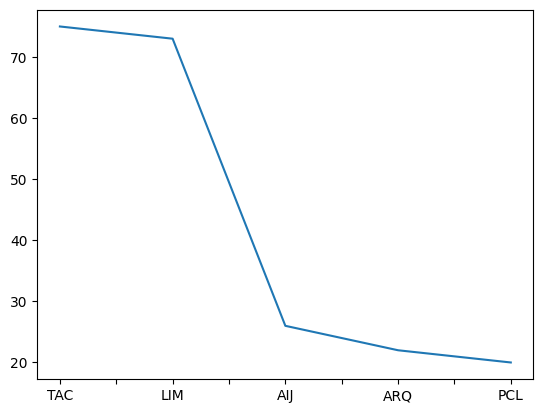

In [14]:
# Campos: ['Id Persona', 'Número Pasaporte', 'Fecha Nacimiento Pasaporte', 'Fecha Nacimiento Persona']
df_1_1 = df_1.groupby(by=['sSigla']).agg({ 'sSigla': [np.ma.count] }) \
             .droplevel(level=0, axis=1) \
             .sort_values(by='count', ascending=False) \
             .head(5)

df_1_1.plot(legend=False, xlabel='')

### 3.2 2. Se define como regla, que la fecha de nacimiento de `SimPersona`, debe ser menor a la fecha actual.

In [18]:
df_2 = pd.read_excel('./anexos/A2.xlsx')

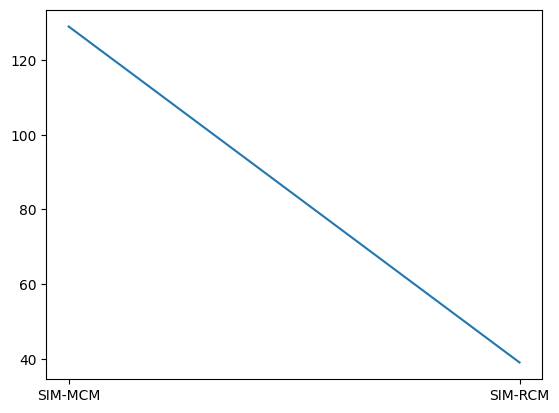

In [32]:
# Columns: ['Login Operador Digita', 'Nombre Operador Digita', 'Id Módulo Digita', 'Nombre Módulo Digita']

df_2_1 = df_2.groupby(by=['Id Módulo Digita']).agg({ 'Login Operador Digita': [np.ma.count] }).droplevel(level=0, axis=1)
df_2_f = df_2_1.plot(legend=False, xlabel='')
labels = ['SIM-MCM', 'SIM-RCM']
df_2_f.set_xticks(range(len(labels)), labels)

### 3.3 3. Se define como regla, que los trámites de Cambio de Calidad `TRABAJADOR` deben registrar una empresa.

In [7]:
df_3 = pd.read_excel('./anexos/A3_A.xlsx')

<Axes: >

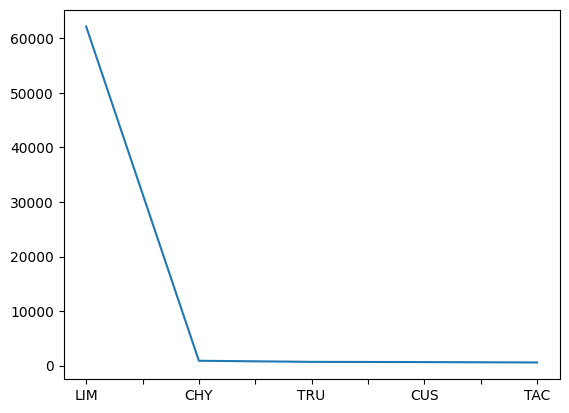

In [20]:
# Columns: ['Número Trámite', 'Tipo Tramite', 'Estado Trámite', 'Calidad Migratoria', 'Empresa']

df_3_1 = df_3.groupby(by=['sSigla']).agg({ 'sSigla': [np.ma.count] }) \
             .droplevel(level=0, axis=1) \
             .sort_values(by='count', ascending=False) \
             .head(5)

df_3_1.plot(legend=False, xlabel='')


### 3.4 4. Se define como regla, que los documentos de viaje `PAS` en el registro de salida del control migratorio, deben estar vigentes.

In [25]:
df_4 = pd.read_excel('./anexos/A4_A.xlsx')

<Axes: >

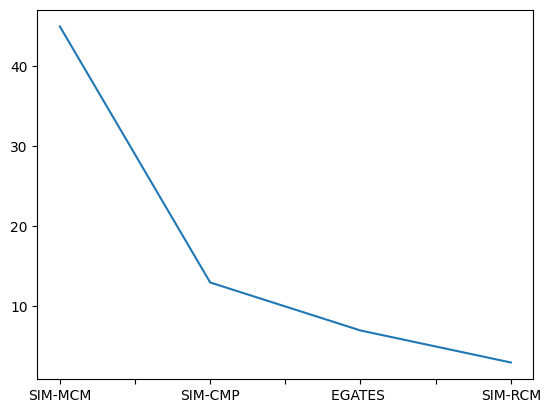

In [26]:
# ['Id Mov Migratorio', 'Tipo Movimiento', 'Fecha Movimiento', 'Documento', 'Número Documento', 'Fecha Emisión Pasaporte', 'Fecha Expiración Pasaporte']

df_4_1 = df_4.groupby(by=['sIdModuloDigita']).agg({ 'sIdModuloDigita': [np.ma.count] }) \
             .droplevel(level=0, axis=1) \
             .sort_values(by='count', ascending=False) \
             .head(5)

df_4_1.plot(legend=False, xlabel='')


### 3.5 5. Se define como regla, que únicamente paises que forman parte de comunidad Andina, pueden registrar un documento de viaje `TAM`.

In [27]:
df_5 = pd.read_excel('./anexos/A5.xlsx')

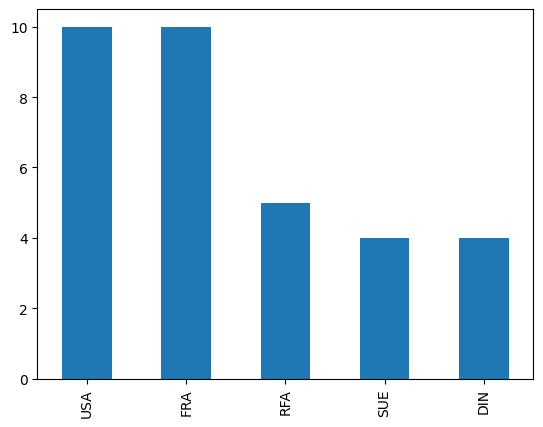

In [31]:
# Columns: ['Nacionalidad', 'Id Mov Migratorio', 'Tipo Movimiento', 'Fecha Movimiento', 'Documento', 'Número Documento', 'Dependencia']

df_5_1 = df_5.groupby(by=['Nacionalidad']).agg({ 'Nacionalidad': [np.ma.count] }) \
             .droplevel(level=0, axis=1) \
             .sort_values(by='count', ascending=False) \
             .head(5)

df_5_f = df_5_1.plot.bar(legend=False, xlabel='')




In [47]:
month = 5
year = 2024
path = f'{year}-{str(month).zfill(2)}'
path

'2024-05'